# PCI Stimulation Sensitivity Tutorial

This notebook tests whether the PCI perturbation is strong enough to evoke a measurable whole-brain response, but not so strong that the stimulated region saturates or remains in an explosive firing-rate state.

We deliberately run a small whole-brain sensitivity sweep:

- one representative subject by default
- one noise scenario by default
- one shared `b_e` value by default
- a compact grid of stimulation amplitudes and durations
- two independent trials per stimulation setting by default

The goal is **not** to estimate final PCI here. The goal is to tune the perturbation before launching expensive HPC simulations.

## 1. Setup

The notebook uses the same `run_pci_trial_job()` function as the HPC PCI pipeline. That means the perturbation enters the whole-brain model through TVB's `StimuliRegion + PulseTrain` path, targeting variable `0`, the excitatory firing rate `E`.

Outputs are written to a dedicated folder so they cannot be mixed with the main HPC outputs.

In [1]:
from __future__ import annotations

import os
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
NOTEBOOKS = PROJECT_ROOT / "notebooks"
for p in (SRC, NOTEBOOKS):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
os.environ.setdefault("TVB_USER_HOME", str(PROJECT_ROOT / ".tvb-temp"))

from brain_act_hybrid_common import (  # noqa: E402
    BASE_PARAMETER_MODEL_NEW,
    DATASET_ROOT,
    RATE_MONITOR_PERIOD_MS_OLD,
    SCENARIOS,
    get_subject_jobs,
)
from tvbtoolkit.complexity.measures import pci_casali_like_multi_trial  # noqa: E402
from tvbtoolkit.workflows.brain_act_dual_domain_parallel import run_pci_trial_job  # noqa: E402

OUT_ROOT = PROJECT_ROOT / "notebooks" / "outputs" / "07_pci_stim_sensitivity"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Output root:  {OUT_ROOT}")

/var/folders/yy/z6qg2k8n2h3g714cbbr9xp040000gn/T/ipykernel_9282/2298796479.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
WARNING    /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)
 [py.warnings]


2026-06-19 18:17:02,879 - WARNING - py.warnings - /Users/borjan/miniconda3/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)

Project root: /Users/borjan/CNRS/projects/TVBToolkit
Dataset root: /Users/borjan/CNRS/projects/TVBToolkit/data/doc_data/converted_structural
Output root:  /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity


## 2. Sensitivity Grid

The current concern is whether `0.00015 kHz` for `10 ms` is underpowered relative to older TVBSim-like settings around `0.0005-0.0007 kHz` for `50 ms`.

The default grid therefore compares:

- amplitudes: `0.00015`, `0.0005`, `0.0007` kHz
- durations: `10`, `50` ms

The amplitude is in kHz because the AdEx/Zerlaut firing-rate variables are stored in kHz internally. Multiply by `1000` to read it as Hz.

In [2]:
# ---- Edit these if you want a larger/smaller diagnostic run ----
COHORT = "control"
SUBJECT_INDEX = 0
SCENARIO_KEY = "private_alpha0"
B_E = 35.0
STIM_REGION = [18]       # 0-based AAL90 index, same default as the HPC PCI script
N_TRIALS_PER_SETTING = 2 # keep small for tutorial; increase for a stronger diagnostic

AMPLITUDES_KHZ = [0.00015, 0.0005, 0.0007]
DURATIONS_MS = [10.0, 50.0]

# Keep the same transient convention as the newer pipeline, but use a short total
# simulation because this notebook only needs the peri-stimulus window.
PCI_TRANSIENT_MS = 4000.0
T_ANALYSIS_MS = 300.0
STIM_ONSET_MS = PCI_TRANSIENT_MS + T_ANALYSIS_MS
TOTAL_SIM_MS = STIM_ONSET_MS + T_ANALYSIS_MS + 100.0
RATE_MONITOR_PERIOD_MS = float(RATE_MONITOR_PERIOD_MS_OLD)

scenario_cfg = SCENARIOS[SCENARIO_KEY]
subject_jobs = [j for j in get_subject_jobs(DATASET_ROOT) if j.cohort == COHORT]
subject = subject_jobs[SUBJECT_INDEX]

print("Subject:", subject)
print("Scenario:", SCENARIO_KEY, scenario_cfg)
print(f"b_e: {B_E} pA")
print(f"Stimulated region(s): {STIM_REGION}")
print(f"Grid: {len(AMPLITUDES_KHZ)} amplitudes x {len(DURATIONS_MS)} durations x {N_TRIALS_PER_SETTING} trials")
print(f"Simulation length: {TOTAL_SIM_MS:.1f} ms, stimulus onset: {STIM_ONSET_MS:.1f} ms")

Subject: SubjectJob(cohort='control', subject_id='c0001', condition='CNT')
Scenario: private_alpha0 {'label': 'Private only (a=0.00)', 'noise_alpha': 0.0, 'shared_noise_mode': 'none'}
b_e: 35.0 pA
Stimulated region(s): [18]
Grid: 3 amplitudes x 2 durations x 2 trials
Simulation length: 4700.0 ms, stimulus onset: 4300.0 ms


## 3. Run Whole-Brain Perturbation Trials

Each grid cell is run as genuine whole-brain TVB simulation. The only things that change across the grid are stimulation amplitude and stimulation duration.

To avoid mixing settings, each condition is saved into its own folder labelled by amplitude and duration.

In [3]:
def amp_tag(amp_khz: float) -> str:
    hz = amp_khz * 1e3
    return f"amp{str(round(hz, 4)).replace('.', 'p')}hz"


def dur_tag(dur_ms: float) -> str:
    return f"dur{int(round(dur_ms)):03d}ms"


def setting_dir(amp_khz: float, dur_ms: float) -> Path:
    return OUT_ROOT / "trials" / f"{amp_tag(amp_khz)}_{dur_tag(dur_ms)}" / subject.cohort / subject.subject_id


base_model = deepcopy(BASE_PARAMETER_MODEL_NEW)
base_model["b_e"] = float(B_E)

rows = []
for amp in AMPLITUDES_KHZ:
    for dur in DURATIONS_MS:
        out_dir = setting_dir(amp, dur)
        for trial_seed in range(N_TRIALS_PER_SETTING):
            expected = out_dir / f"trial_{trial_seed:03d}.npz"
            if expected.exists():
                print(f"skip existing {expected.relative_to(PROJECT_ROOT)}")
                rows.append({
                    "amp_khz": amp,
                    "amp_hz": amp * 1e3,
                    "duration_ms": dur,
                    "trial_seed": trial_seed,
                    "save_path": str(expected),
                    "runtime_s": np.nan,
                    "skipped_existing": True,
                })
                continue

            print(f"run amp={amp*1e3:.2f} Hz, dur={dur:.0f} ms, trial={trial_seed}")
            result = run_pci_trial_job(
                scenario_key=SCENARIO_KEY,
                noise_alpha=float(scenario_cfg["noise_alpha"]),
                shared_noise_mode=str(scenario_cfg["shared_noise_mode"]),
                cohort=subject.cohort,
                subject_id=subject.subject_id,
                trial_seed=int(trial_seed),
                dataset_root=str(DATASET_ROOT),
                output_dir=str(out_dir),
                transient_ms=float(PCI_TRANSIENT_MS),
                t_analysis_ms=float(T_ANALYSIS_MS),
                rate_monitor_period_ms=float(RATE_MONITOR_PERIOD_MS),
                base_parameter_model=deepcopy(base_model),
                stim_amplitude=float(amp),
                stim_duration_ms=float(dur),
                stim_region=list(STIM_REGION),
                stim_onset_ms=float(STIM_ONSET_MS),
                total_sim_ms=float(TOTAL_SIM_MS),
            )
            rows.append({
                "amp_khz": amp,
                "amp_hz": amp * 1e3,
                "duration_ms": dur,
                "trial_seed": trial_seed,
                "save_path": result["save_path"],
                "runtime_s": result["runtime_s"],
                "skipped_existing": False,
            })

run_df = pd.DataFrame(rows)
run_df.to_csv(OUT_ROOT / "trial_run_index.csv", index=False)
run_df

run amp=0.15 Hz, dur=10 ms, trial=0
run amp=0.15 Hz, dur=10 ms, trial=1
run amp=0.15 Hz, dur=50 ms, trial=0
run amp=0.15 Hz, dur=50 ms, trial=1
run amp=0.50 Hz, dur=10 ms, trial=0
run amp=0.50 Hz, dur=10 ms, trial=1
run amp=0.50 Hz, dur=50 ms, trial=0
run amp=0.50 Hz, dur=50 ms, trial=1
run amp=0.70 Hz, dur=10 ms, trial=0
run amp=0.70 Hz, dur=10 ms, trial=1
run amp=0.70 Hz, dur=50 ms, trial=0
run amp=0.70 Hz, dur=50 ms, trial=1


,amp_khz,amp_hz,duration_ms,trial_seed,save_path,runtime_s,skipped_existing
0,0.00015,0.15,10.0,0,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.038300,False
1,0.00015,0.15,10.0,1,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.105668,False
2,0.00015,0.15,50.0,0,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.397652,False
3,0.00015,0.15,50.0,1,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.671413,False
4,0.00050,0.50,10.0,0,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.150816,False
5,0.00050,0.50,10.0,1,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.656755,False
6,0.00050,0.50,50.0,0,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.650462,False
7,0.00050,0.50,50.0,1,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.219684,False
8,0.00070,0.70,10.0,0,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.142728,False
9,0.00070,0.70,10.0,1,/Users/borjan/CNRS/projects/TVBToolkit/noteboo...,57.208535,False


## 4. Load And Align Trials

We now load every trial and align the firing-rate activity to stimulation onset.

The saved rates are in kHz, so we convert to Hz for plotting and diagnostics.

In [4]:
def load_trial(path: Path) -> dict:
    d = np.load(path, allow_pickle=True)
    return {
        "path": Path(path),
        "time_ms": np.asarray(d["time_ms"], dtype=float),
        "rate_hz": np.asarray(d["rate"], dtype=float) * 1e3,
        "region_labels": np.asarray(d["region_labels"]).astype(str),
        "stim_onset_ms": float(d["stim_onset_ms"][0]),
        "t_analysis_ms": float(d["t_analysis_ms"][0]),
        "stim_amplitude": float(d["stim_amplitude"][0]),
        "stim_duration_ms": float(d["stim_duration_ms"][0]),
        "stim_region": np.asarray(d["stim_region"], dtype=int).tolist(),
    }


def align_trial(trial: dict, pre_ms: float = T_ANALYSIS_MS, post_ms: float = T_ANALYSIS_MS) -> tuple[np.ndarray, np.ndarray]:
    t_rel = trial["time_ms"] - trial["stim_onset_ms"]
    dt = float(np.median(np.diff(trial["time_ms"])))
    n_bins = int(round((pre_ms + post_ms) / dt))
    t_common = np.linspace(-pre_ms, post_ms, n_bins)
    aligned = np.column_stack([
        np.interp(t_common, t_rel, trial["rate_hz"][:, reg])
        for reg in range(trial["rate_hz"].shape[1])
    ])
    return t_common, aligned

trials_by_setting = {}
for amp in AMPLITUDES_KHZ:
    for dur in DURATIONS_MS:
        paths = sorted(setting_dir(amp, dur).glob("trial_*.npz"))[:N_TRIALS_PER_SETTING]
        trials_by_setting[(amp, dur)] = [load_trial(p) for p in paths]
        print(f"amp={amp*1e3:.2f} Hz, dur={dur:.0f} ms: {len(paths)} trial(s)")

first_trial = next(iter(next(iter(trials_by_setting.values()))))
print("Rate matrix example:", first_trial["rate_hz"].shape, "time x regions")
print("First region labels:", first_trial["region_labels"][:5])

amp=0.15 Hz, dur=10 ms: 2 trial(s)
amp=0.15 Hz, dur=50 ms: 2 trial(s)
amp=0.50 Hz, dur=10 ms: 2 trial(s)
amp=0.50 Hz, dur=50 ms: 2 trial(s)
amp=0.70 Hz, dur=10 ms: 2 trial(s)
amp=0.70 Hz, dur=50 ms: 2 trial(s)
Rate matrix example: (89, 90) time x regions
First region labels: ['R000' 'R001' 'R002' 'R003' 'R004']


## 5. Propagation And Saturation Metrics

For each stimulation setting, we compute a few simple diagnostics:

- **stimulated-region peak ΔHz**: how strongly the directly stimulated node responds
- **whole-brain peak ΔHz**: maximum response anywhere in the network
- **spread**: number of regions exceeding `baseline + 1 Hz` after stimulation
- **late residual ΔHz**: whether activity remains elevated near the end of the post-stimulus window
- **saturation flags**: whether the stimulated region becomes very high or fails to recover

These are not final PCI statistics. They are safety/tuning diagnostics.

In [5]:
def compute_setting_metrics(trials: list[dict], threshold_delta_hz: float = 1.0) -> dict:
    aligned_stack = []
    t_common = None
    for tr in trials:
        t_common, aligned = align_trial(tr)
        aligned_stack.append(aligned)
    stack = np.stack(aligned_stack, axis=0)  # trials x time x regions
    mean_rate = stack.mean(axis=0)

    pre_mask = t_common < 0
    post_mask = t_common >= 0
    late_mask = t_common >= (T_ANALYSIS_MS - 100.0)

    baseline = mean_rate[pre_mask].mean(axis=0)
    delta = mean_rate - baseline[np.newaxis, :]
    post_delta = delta[post_mask]

    stim_idx = STIM_REGION[0]
    stim_peak_delta = float(post_delta[:, stim_idx].max())
    wb_peak_delta = float(post_delta.max())
    spread_regions = int(np.sum(post_delta.max(axis=0) > threshold_delta_hz))
    late_residual_stim = float(delta[late_mask, stim_idx].mean())
    late_residual_wb = float(delta[late_mask].mean())
    stim_abs_peak = float(mean_rate[post_mask, stim_idx].max())

    explosive_abs = stim_abs_peak > 100.0
    poor_recovery = late_residual_stim > max(5.0, 0.25 * max(stim_peak_delta, 1e-9))

    return {
        "t_common": t_common,
        "mean_rate": mean_rate,
        "delta": delta,
        "baseline": baseline,
        "stim_peak_delta_hz": stim_peak_delta,
        "whole_brain_peak_delta_hz": wb_peak_delta,
        "spread_regions_gt_1hz": spread_regions,
        "late_residual_stim_delta_hz": late_residual_stim,
        "late_residual_wb_delta_hz": late_residual_wb,
        "stim_abs_peak_hz": stim_abs_peak,
        "explosive_abs_flag": bool(explosive_abs),
        "poor_recovery_flag": bool(poor_recovery),
    }

metrics = {}
summary_rows = []
for (amp, dur), trials in trials_by_setting.items():
    if not trials:
        continue
    m = compute_setting_metrics(trials)
    metrics[(amp, dur)] = m
    summary_rows.append({
        "amp_khz": amp,
        "amp_hz": amp * 1e3,
        "duration_ms": dur,
        "n_trials": len(trials),
        "stim_peak_delta_hz": m["stim_peak_delta_hz"],
        "whole_brain_peak_delta_hz": m["whole_brain_peak_delta_hz"],
        "spread_regions_gt_1hz": m["spread_regions_gt_1hz"],
        "late_residual_stim_delta_hz": m["late_residual_stim_delta_hz"],
        "late_residual_wb_delta_hz": m["late_residual_wb_delta_hz"],
        "stim_abs_peak_hz": m["stim_abs_peak_hz"],
        "explosive_abs_flag": m["explosive_abs_flag"],
        "poor_recovery_flag": m["poor_recovery_flag"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["duration_ms", "amp_hz"])
summary_df.to_csv(OUT_ROOT / "stim_sensitivity_summary.csv", index=False)
summary_df

,amp_khz,amp_hz,duration_ms,n_trials,stim_peak_delta_hz,whole_brain_peak_delta_hz,spread_regions_gt_1hz,late_residual_stim_delta_hz,late_residual_wb_delta_hz,stim_abs_peak_hz,explosive_abs_flag,poor_recovery_flag
0,0.00015,0.15,10.0,2,5.462388,7.503821,90,0.057165,0.474603,7.414021,False,False
2,0.00050,0.50,10.0,2,15.226443,15.226443,90,-0.050307,0.513941,17.178076,False,False
4,0.00070,0.70,10.0,2,24.749392,24.749392,90,-0.733937,0.526420,26.701024,False,False
1,0.00015,0.15,50.0,2,7.969994,7.969994,90,0.006049,0.499823,9.921627,False,False
3,0.00050,0.50,50.0,2,19.376170,19.376170,90,-1.294264,0.517745,21.327803,False,False
5,0.00070,0.70,50.0,2,32.245569,32.245569,90,-1.707880,0.530276,34.197202,False,False


## 6. Summary Heatmaps

These panels show how response strength, spread, and recovery change as amplitude and duration increase.

The ideal PCI perturbation should be visible and distributed, but not explosive.

Saved /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/fig01_summary_heatmaps.png


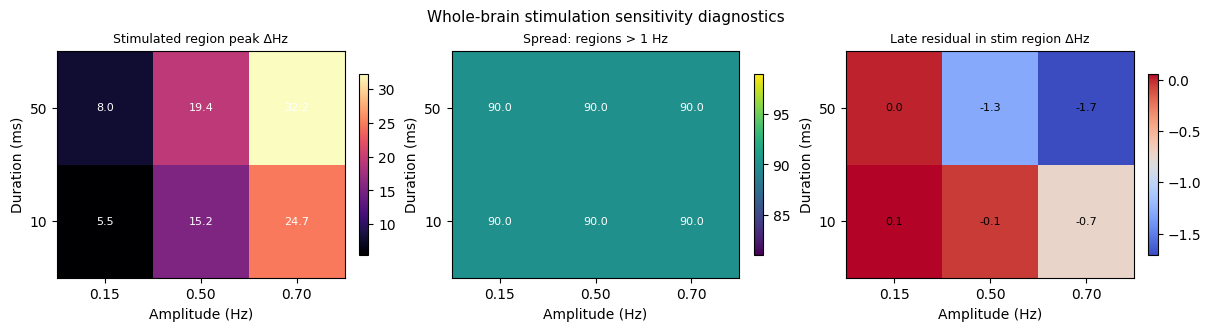

In [6]:
def pivot_metric(metric: str) -> pd.DataFrame:
    return summary_df.pivot(index="duration_ms", columns="amp_hz", values=metric).sort_index()

plot_specs = [
    ("stim_peak_delta_hz", "Stimulated region peak ΔHz", "magma"),
    ("spread_regions_gt_1hz", "Spread: regions > 1 Hz", "viridis"),
    ("late_residual_stim_delta_hz", "Late residual in stim region ΔHz", "coolwarm"),
]

fig, axes = plt.subplots(1, len(plot_specs), figsize=(12, 3.2), constrained_layout=True)
for ax, (metric, title, cmap) in zip(axes, plot_specs):
    mat = pivot_metric(metric)
    im = ax.imshow(mat.values, aspect="auto", cmap=cmap, origin="lower")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Amplitude (Hz)")
    ax.set_ylabel("Duration (ms)")
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels([f"{c:.2f}" for c in mat.columns])
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels([f"{i:.0f}" for i in mat.index])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color="white" if metric != "late_residual_stim_delta_hz" else "black")
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Whole-brain stimulation sensitivity diagnostics", fontsize=11)
out = OUT_ROOT / "fig01_summary_heatmaps.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved {out}")
plt.show()

## 7. Propagation Plot For Each Setting

Each panel shows the baseline-corrected regional response after stimulation.

Rows are regions sorted by time-to-peak response. This makes propagation easier to see: early-responding regions appear near the top, later-responding regions lower down.

Saved /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/fig02_propagation_heatmaps.png


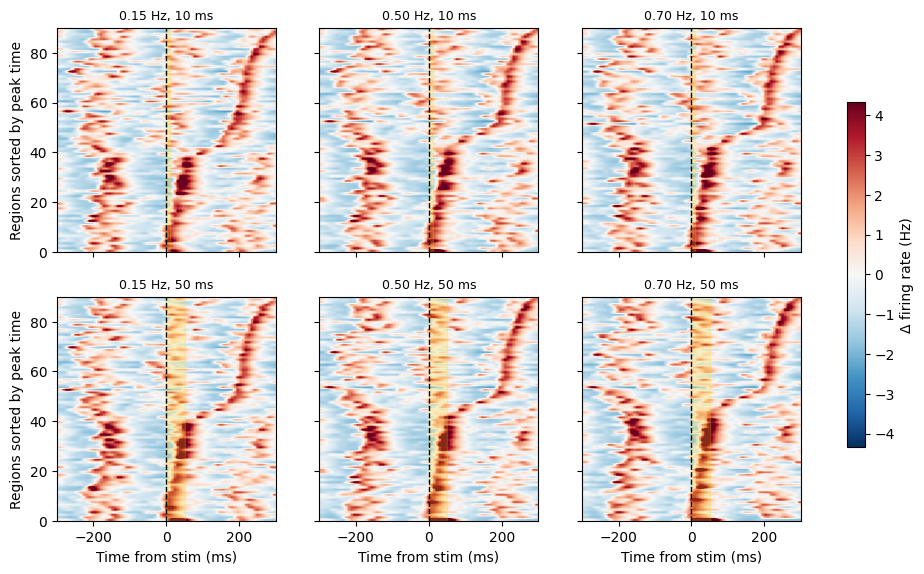

In [7]:
fig, axes = plt.subplots(len(DURATIONS_MS), len(AMPLITUDES_KHZ), figsize=(4.0 * len(AMPLITUDES_KHZ), 3.2 * len(DURATIONS_MS)), sharex=True, sharey=True)
if len(DURATIONS_MS) == 1:
    axes = np.atleast_2d(axes)

vmax = max(float(np.percentile(np.abs(m["delta"]), 99)) for m in metrics.values())
vmax = max(vmax, 1.0)

for i, dur in enumerate(DURATIONS_MS):
    for j, amp in enumerate(AMPLITUDES_KHZ):
        ax = axes[i, j]
        m = metrics[(amp, dur)]
        t = m["t_common"]
        delta = m["delta"]
        post = delta[t >= 0]
        t_post = t[t >= 0]
        peak_times = t_post[np.argmax(post, axis=0)]
        order = np.argsort(peak_times)
        if STIM_REGION[0] in order:
            order = np.r_[STIM_REGION[0], order[order != STIM_REGION[0]]]

        im = ax.imshow(delta[:, order].T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       extent=[t[0], t[-1], 0, delta.shape[1]])
        ax.axvline(0, color="black", lw=1.0, ls="--")
        ax.axvspan(0, dur, color="gold", alpha=0.2)
        ax.set_title(f"{amp*1e3:.2f} Hz, {dur:.0f} ms", fontsize=9)
        if i == len(DURATIONS_MS) - 1:
            ax.set_xlabel("Time from stim (ms)")
        if j == 0:
            ax.set_ylabel("Regions sorted by peak time")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Δ firing rate (Hz)")
out = OUT_ROOT / "fig02_propagation_heatmaps.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved {out}")
plt.show()

## 8. Trial-Averaged Regional Traces

This plot overlays all regional responses for each stimulation setting. The stimulated region is drawn thicker and darker.

Use this to judge whether the stimulated region behaves physiologically or enters a runaway/explosive state.

Saved /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/fig03_regional_traces.png


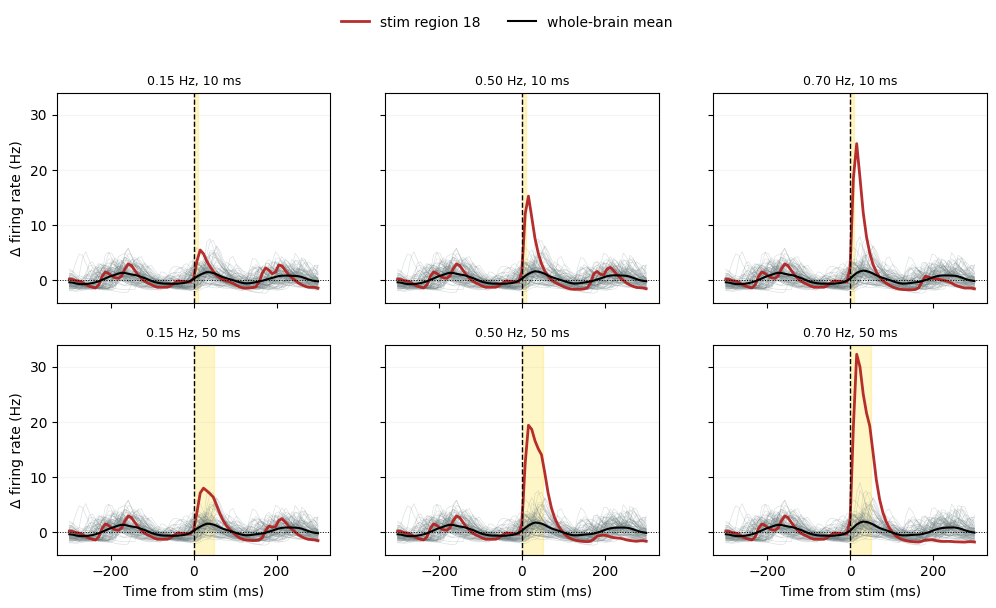

In [8]:
fig, axes = plt.subplots(len(DURATIONS_MS), len(AMPLITUDES_KHZ), figsize=(4.0 * len(AMPLITUDES_KHZ), 3.0 * len(DURATIONS_MS)), sharex=True, sharey=True)
if len(DURATIONS_MS) == 1:
    axes = np.atleast_2d(axes)

for i, dur in enumerate(DURATIONS_MS):
    for j, amp in enumerate(AMPLITUDES_KHZ):
        ax = axes[i, j]
        m = metrics[(amp, dur)]
        t = m["t_common"]
        delta = m["delta"]
        stim_idx = STIM_REGION[0]

        for reg in range(delta.shape[1]):
            if reg == stim_idx:
                continue
            ax.plot(t, delta[:, reg], color="#6E7F80", lw=0.45, alpha=0.25)
        ax.plot(t, delta[:, stim_idx], color="#B22222", lw=2.0, alpha=0.95, label=f"stim region {stim_idx}")
        ax.plot(t, delta.mean(axis=1), color="black", lw=1.5, label="whole-brain mean")
        ax.axhline(0, color="black", lw=0.7, ls=":")
        ax.axvline(0, color="black", lw=1.0, ls="--")
        ax.axvspan(0, dur, color="gold", alpha=0.22)
        ax.set_title(f"{amp*1e3:.2f} Hz, {dur:.0f} ms", fontsize=9)
        if i == len(DURATIONS_MS) - 1:
            ax.set_xlabel("Time from stim (ms)")
        if j == 0:
            ax.set_ylabel("Δ firing rate (Hz)")
        ax.grid(alpha=0.12, axis="y")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
out = OUT_ROOT / "fig03_regional_traces.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved {out}")
plt.show()

## 9. Casali-Like PCI From The Tiny Diagnostic Trials

This is not a final PCI estimate because the tutorial uses very few trials. It is still useful as a quick check that the binarisation/Lempel-Ziv pipeline behaves sensibly across stimulation settings.

In [9]:
def trial_windows_for_pci(trials: list[dict]) -> tuple[list[np.ndarray], float]:
    windows = []
    dt_ref = None
    for tr in trials:
        t = tr["time_ms"]
        x = tr["rate_hz"] / 1e3  # back to kHz, matching stored pipeline units
        dt = float(np.median(np.diff(t)))
        dt_ref = dt if dt_ref is None else dt_ref
        nbins = int(round(T_ANALYSIS_MS / dt))
        stim_idx = int(round((tr["stim_onset_ms"] - t[0]) / dt))
        win = x[stim_idx - nbins: stim_idx + nbins, :]
        windows.append(win.T)
    return windows, float(dt_ref)

pci_rows = []
for (amp, dur), trials in trials_by_setting.items():
    windows, dt_ms = trial_windows_for_pci(trials)
    np.random.seed(0)
    pci_mean, pci_trials = pci_casali_like_multi_trial(
        windows,
        stimulation_index=int(round(T_ANALYSIS_MS / dt_ms)),
        t_analysis_ms=T_ANALYSIS_MS,
        dt_ms=dt_ms,
        nshuffles=10,
        percentile=100.0,
    )
    pci_rows.append({
        "amp_khz": amp,
        "amp_hz": amp * 1e3,
        "duration_ms": dur,
        "n_trials": len(trials),
        "pci_mean_tiny_diagnostic": pci_mean,
        "pci_trials": list(map(float, pci_trials)),
    })

pci_df = pd.DataFrame(pci_rows).sort_values(["duration_ms", "amp_hz"])
pci_df.to_csv(OUT_ROOT / "tiny_diagnostic_pci.csv", index=False)
pci_df

,amp_khz,amp_hz,duration_ms,n_trials,pci_mean_tiny_diagnostic,pci_trials
0,0.00015,0.15,10.0,2,0.759851,"[0.7881566068824872, 0.7315459632243825]"
2,0.00050,0.50,10.0,2,0.802617,"[0.7917345633117437, 0.8134985349624076]"
4,0.00070,0.70,10.0,2,0.744505,"[0.7590056378237688, 0.7300050510960095]"
1,0.00015,0.15,50.0,2,0.768999,"[0.7999402260463675, 0.7380576437651849]"
3,0.00050,0.50,50.0,2,0.686965,"[0.7443801029300734, 0.629550155180068]"
5,0.00070,0.70,50.0,2,0.737420,"[0.8022522104454746, 0.6725876242899426]"


## 10. Interpretation Helper

A reasonable stimulation setting should satisfy three things:

1. It visibly perturbs the stimulated region.
2. The response propagates beyond the stimulated node.
3. The stimulated region recovers rather than remaining in a high-firing state.

If a setting has tiny `stim_peak_delta_hz` and tiny spread, it is probably underpowered. If it has high late residuals or saturation flags, it is probably too strong.

In [10]:
display_cols = [
    "amp_hz", "duration_ms", "stim_peak_delta_hz", "whole_brain_peak_delta_hz",
    "spread_regions_gt_1hz", "late_residual_stim_delta_hz", "stim_abs_peak_hz",
    "explosive_abs_flag", "poor_recovery_flag",
]
print("Saved outputs:")
for p in sorted(OUT_ROOT.glob("fig*.png")):
    print(" -", p)
print(" -", OUT_ROOT / "stim_sensitivity_summary.csv")
print(" -", OUT_ROOT / "tiny_diagnostic_pci.csv")

summary_df[display_cols]

Saved outputs:
 - /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/fig01_summary_heatmaps.png
 - /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/fig02_propagation_heatmaps.png
 - /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/fig03_regional_traces.png
 - /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/stim_sensitivity_summary.csv
 - /Users/borjan/CNRS/projects/TVBToolkit/notebooks/outputs/07_pci_stim_sensitivity/tiny_diagnostic_pci.csv


,amp_hz,duration_ms,stim_peak_delta_hz,whole_brain_peak_delta_hz,spread_regions_gt_1hz,late_residual_stim_delta_hz,stim_abs_peak_hz,explosive_abs_flag,poor_recovery_flag
0,0.15,10.0,5.462388,7.503821,90,0.057165,7.414021,False,False
2,0.50,10.0,15.226443,15.226443,90,-0.050307,17.178076,False,False
4,0.70,10.0,24.749392,24.749392,90,-0.733937,26.701024,False,False
1,0.15,50.0,7.969994,7.969994,90,0.006049,9.921627,False,False
3,0.50,50.0,19.376170,19.376170,90,-1.294264,21.327803,False,False
5,0.70,50.0,32.245569,32.245569,90,-1.707880,34.197202,False,False
